<a href="https://colab.research.google.com/github/sean-seah/HPDP/blob/main/2526/assignment/A2/Group%20TehOAis/big_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup & Environment Verification**

Since this assignment are working on the Google Colab free tier, managing the system memory (RAM) carefully is crucial to prevent kernel crashes when handling a dataset of this size.  This initial cell to mount Google Drive where the dataset should be stored for persistence and install polars along with memory_profiler to track the RAM usage.

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Install required libraries for Partner A
!pip install polars memory_profiler matplotlib seaborn

# Step 3: Verify available RAM allocation
import psutil
virtual_mem = psutil.virtual_memory()
print(f"Total available RAM: {virtual_mem.total / (1024**3):.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total available RAM: 12.67 GB


**Task 1: Dataset Selection (Report Metadata)**

Below is the structured metadata of the dataset:


*   Dataset Name: NYC Yellow Taxi Trip Data (January 2016)
*   Source URL: Kaggle - NYC Yellow Taxi Trip Data   

*   File Size: ~1.59 GB (Uncompressed CSV), which satisfies the hard threshold of > 700 MB.  
*   Domain: Transportation / Urban Logistics

*   Approximate Number of Records: ~10.9 million rows.


**Task 2: Initial Data Loading & Inspection (Pandas Baseline)**

To prevent Google Colab from running out of memory during the initial inspection, only the first 10,000 rows are read using Pandas. This allows the code to safely extract metadata without triggering a kernel crash.

In [ ]:
import pandas as pd
import time
import os
from memory_profiler import memory_usage

# Change this path to where you saved the file in your Google Drive
DATASET_PATH = '/content/drive/MyDrive/HPDP_Assignment2/yellow_tripdata_2016-01.csv'

def inspect_initial_data():
    print("--- TASK 2: INITIAL DATA INSPECTION (PANDAS BASELINE) ---")

    # Read a small subset safely to inspect schema
    preview_df = pd.read_csv(DATASET_PATH, nrows=10000)

    print(f"Dataset Sample Shape: {preview_df.shape}")
    print("\nColumns and Inferred Data Types:")
    print(preview_df.dtypes)

    print("\nMissing Values Sample (First 10k rows):")
    print(preview_df.isnull().sum())

    print("\nData Preview:")
    display(preview_df.head())

inspect_initial_data()

--- TASK 2: INITIAL DATA INSPECTION (PANDAS BASELINE) ---
Dataset Sample Shape: (10000, 19)

Columns and Inferred Data Types:
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

Missing Values Sample (First 10k rows):
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
Rat

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


**Strategy 1: Load Less Data (Column Selection)**

Instead of loading all 19 columns of the massive 1.59 GB NYC Taxi CSV file, selectively target and load only the 8 columns essential for our analysis. By ignoring the other 11 columns, Pandas never allocates memory for them, which immediately scales down the memory footprint and speeds up execution times from the very beginning of the data pipeline.

In [ ]:
import pandas as pd
import time
from memory_profiler import memory_usage


def run_strategy_1():
    print("--- STRATEGY 1: LOADING LESS DATA (COLUMN SELECTION) ---")

    # Define only the 8 columns we actually need (ignoring the rest)
    keep_columns = [
        'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
        'passenger_count', 'trip_distance', 'pickup_longitude',
        'pickup_latitude', 'fare_amount'
    ]

    start_time = time.time()

    # Load the dataset using only the specified columns
    df_less_data = pd.read_csv(
        DATASET_PATH,
        usecols=keep_columns
    )

    end_time = time.time()

    # Calculate internal dataframe memory footprint
    internal_mem = df_less_data.memory_usage(deep=True).sum() / (1024**2)

    print(f"Execution Time: {end_time - start_time:.2f} seconds")
    print(f"Columns Loaded: {list(df_less_data.columns)}")
    print(f"Internal Dataframe Memory Footprint: {internal_mem:.2f} MB")
    print(f"Total Rows Processed: {len(df_less_data):,}\n")

    return end_time - start_time, internal_mem

# Profile and capture peak system RAM for Strategy 1
mem_s1, (time_s1, df_mem_s1) = memory_usage((run_strategy_1, ()), retval=True)
peak_ram_s1 = max(mem_s1)
print(f"Peak System RAM Consumed during Strategy 1: {peak_ram_s1:.2f} MB")

--- STRATEGY 1: LOADING LESS DATA (COLUMN SELECTION) ---
Execution Time: 65.33 seconds
Columns Loaded: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'fare_amount']
Internal Dataframe Memory Footprint: 1913.89 MB
Total Rows Processed: 10,906,858

Peak System RAM Consumed during Strategy 1: 2367.07 MB


**Strategy 2: Chunking (Pandas)**

Loading all millions of rows at once which can cause severe system performance bottlenecks or crashes. To calculate the average taxi's fare amount in New York city, chunking strategy is applied to process the dataset incrementally in controlled blocks of 100,000 rows.

During each loop iteration, a single chunk is streamed into RAM to update global running totals (total_fare and total_trips) before Python discards it to make room for the next batch.

In [ ]:
import pandas as pd
import time
import tracemalloc

print("--- STRATEGY 2: CHUNKING (PANDAS) ---")

# 1. Start profiles
tracemalloc.start()
start_time = time.time()

chunk_size = 100000  # Process 100k rows at a time
total_fare = 0.0
total_trips = 0

# 2. Iterate through the file incrementally using your DATASET_PATH
for chunk in pd.read_csv(DATASET_PATH, chunksize=chunk_size):
    # Filter out potential anomalies (negative fares) and calculate running totals
    valid_fares = chunk[chunk['fare_amount'] > 0]['fare_amount']
    total_fare += valid_fares.sum()
    total_trips += valid_fares.count()

overall_mean_fare = total_fare / total_trips

# 3. Stop profiles and capture metrics
end_time = time.time()
_, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Convert metrics
execution_time_s2 = end_time - start_time
peak_memory_mb_s2 = peak_memory / (1024 * 1024)

print(f"Overall Average Fare: ${overall_mean_fare:.2f}")
print(f"Execution Time: {execution_time_s2:.4f} seconds")
print(f"Peak Memory Usage: {peak_memory_mb_s2:.2f} MB")

--- STRATEGY 2: CHUNKING (PANDAS) ---
Overall Average Fare: $12.50
Execution Time: 77.9678 seconds
Peak Memory Usage: 89.31 MB


**Strategy 3: Data Type Optimization (Downcasting)**

By default, Pandas assigns massive 64-bit data types (int64 and float64) to numeric data types. For example, a passenger_count rarely exceeds 6, meaning it can easily fit into an 8-bit integer (int8) instead of an int64.  

To minimize memory allocation, pass a customized dtype dictionary directly into pd.read_csv(). This handles downcasting at load time, lowering the initial memory peak and preventing out-of-memory kernel crashes on the Colab free tier.

In [ ]:
def run_strategy_3():
    print("--- STRATEGY 3: DATA TYPE OPTIMIZATION (DOWNCASTING) ---")

    # We still keep columns filtered so we don't crash, but now we strictly optimize types
    keep_columns = [
        'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
        'passenger_count', 'trip_distance', 'pickup_longitude',
        'pickup_latitude', 'fare_amount'
    ]

    # Define tight, optimized memory spaces (Strategy 3 Core)
    optimized_dtypes = {
        'VendorID': 'int8',            # Fits comfortably in 8-bit int (values are 1 or 2)
        'passenger_count': 'int8',     # Small integer space
        'trip_distance': 'float32',    # 32-bit float cuts float64 memory usage in half
        'pickup_longitude': 'float32',
        'pickup_latitude': 'float32',
        'fare_amount': 'float32'
    }

    start_time = time.time()

    # Load dataset with strict data type declarations
    df_optimized = pd.read_csv(
        DATASET_PATH,
        usecols=keep_columns,
        dtype=optimized_dtypes,
        parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime']
    )

    end_time = time.time()

    # Calculate internal dataframe memory footprint
    internal_mem = df_optimized.memory_usage(deep=True).sum() / (1024**2)

    print(f"Execution Time: {end_time - start_time:.2f} seconds")
    print("\nOptimized Column Data Types Result:")
    print(df_optimized.dtypes)
    print(f"\nInternal Dataframe Memory Footprint: {internal_mem:.2f} MB")
    print(f"Total Rows Processed: {len(df_optimized):,}\n")

    return end_time - start_time, internal_mem

# Profile and capture peak system RAM for Strategy 3
mem_s3, (time_s3, df_mem_s3) = memory_usage((run_strategy_3, ()), retval=True)
peak_ram_s3 = max(mem_s3)
print(f"Peak System RAM Consumed during Strategy 3: {peak_ram_s3:.2f} MB")

--- STRATEGY 3: DATA TYPE OPTIMIZATION (DOWNCASTING) ---
Execution Time: 138.24 seconds

Optimized Column Data Types Result:
VendorID                           int8
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                    int8
trip_distance                   float32
pickup_longitude                float32
pickup_latitude                 float32
fare_amount                     float32
dtype: object

Internal Dataframe Memory Footprint: 353.65 MB
Total Rows Processed: 10,906,858

Peak System RAM Consumed during Strategy 3: 5264.15 MB


**Strategy 4: Sampling (Pandas)**

This strategy extracts a random, statistically representative 10% slice from an initial 500,000-row upper bound of the dataset.

Using a fixed random_state ensures that the sample remains identical every time the code is run, allowing for instant, lightweight prototyping of data manipulation workflows without putting any strain on system memory.

In [ ]:
import pandas as pd
import time
import tracemalloc

print("--- STRATEGY 4: SAMPLING (PANDAS) ---")

# 1. Start profiles
tracemalloc.start()
start_time = time.time()

# 2. Read an upper bound, then sample randomly
# nrowd is adjusted depending on memory that is left
df_sample = pd.read_csv(DATASET_PATH, nrows=500000).sample(frac=0.1, random_state=42)

# Calculate a quick metric on the sample to simulate an analysis workflow
sample_avg_distance = df_sample['trip_distance'].mean()

# 3. Stop profiles and capture metrics
end_time = time.time()
_, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

execution_time_s4 = end_time - start_time
peak_memory_mb_s4 = peak_memory / (1024 * 1024)

print(f"Sample Shape: {df_sample.shape} (10% of 500k rows)")
print(f"Sample Average Trip Distance: {sample_avg_distance:.2f} miles")
print(f"Execution Time: {execution_time_s4:.4f} seconds")
print(f"Peak Memory Usage: {peak_memory_mb_s4:.2f} MB")

--- STRATEGY 4: SAMPLING (PANDAS) ---
Sample Shape: (50000, 19) (10% of 500k rows)
Sample Average Trip Distance: 3.23 miles
Execution Time: 3.8214 seconds
Peak Memory Usage: 253.48 MB


**Strategy 5: Parallel Processing (Polars Baseline Comparison)**


The best strategy to choose for the comparison is Strategy 3: Data Type Optimization (Combined with a complete read) or a GroupBy Aggregation operation over the data. However, keeping Google Colab's free-tier memory limit (~12GB) in mind, the absolute best option is evaluating the execution time and memory footprint of parsing the file and optimizing/downcasting data types.

**Pandas' Weakness vs. Polars' Strength:**

When Pandas reads a dataset, it defaults to heavy 64-bit types (int64, float64). Downcasting forces Pandas to process the data row-by-row or convert it in steps, causing a massive memory spike. Polars, written in Rust, handles types natively and optimizes memory allocation on the fly.

In [ ]:
import polars as pl
import time
from memory_profiler import memory_usage

def run_strategy_5_polars():
    print("--- STRATEGY 5: PARALLEL PROCESSING (POLARS WORKFLOW) ---")

    # Define a schema override to optimize types during ingestion
    polars_dtypes = {
        'VendorID': pl.Int8,
        'passenger_count': pl.Int8,
        'trip_distance': pl.Float32,
        'pickup_longitude': pl.Float32,
        'pickup_latitude': pl.Float32,
        'fare_amount': pl.Float32
    }

    keep_columns = [
        'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
        'passenger_count', 'trip_distance', 'pickup_longitude',
        'pickup_latitude', 'fare_amount'
    ]

    start_time = time.time()

    # We load columns and apply datatypes natively at scan time
    query = (
        pl.scan_csv(DATASET_PATH, dtypes=polars_dtypes)
        .select(keep_columns)
        .with_columns([
            pl.col("tpep_pickup_datetime").str.to_datetime(),
            pl.col("tpep_dropoff_datetime").str.to_datetime()
        ])
    )

    df_polars = query.collect()

    end_time = time.time()
    internal_mem = df_polars.estimated_size("mb")

    print(f"Execution Time: {end_time - start_time:.2f} seconds")
    print(f"Polars Internal Memory Footprint: {internal_mem:.2f} MB")
    print(f"Total Rows Processed: {len(df_polars):,}\n")

    return end_time - start_time, internal_mem

# Profile and capture peak system RAM for Polars
mem_pl, (time_pl, df_mem_pl) = memory_usage((run_strategy_5_polars, ()), retval=True)
peak_ram_pl = max(mem_pl)
print(f"Peak System RAM Consumed during Polars Execution: {peak_ram_pl:.2f} MB")

--- STRATEGY 5: PARALLEL PROCESSING (POLARS WORKFLOW) ---


/tmp/ipykernel_2759/4023240147.py:28: DeprecationWarning: the argument `dtypes` for `scan_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  pl.scan_csv(DATASET_PATH, dtypes=polars_dtypes)


Execution Time: 19.14 seconds
Polars Internal Memory Footprint: 353.65 MB
Total Rows Processed: 10,906,858

Peak System RAM Consumed during Polars Execution: 2950.38 MB


**Strategy 5: Parallel Processing (Dask Implementation)**

While Strategy 3 uses Pandas to process columns sequentially on a single CPU thread, this strategy re-implements the exact same column filtering and downcasting logic using Dask to exploit multi-core parallelism. By utilizing lazy evaluation, Dask breaks the multi-gigabyte CSV file into smaller virtual partitions and schedules the compressed data type conversions across all available processor cores simultaneously. When .compute() is triggered, the parallel execution cuts down processing bottlenecks significantly, demonstrating how framework architecture can drastically accelerate data pipelines even when using identical data schemas.

In [ ]:
import dask.dataframe as dd
import time

def run_strategy_5_dask():
    print("--- STRATEGY 5: PARALLEL PROCESSING (DASK DATA TYPE OPTIMIZATION) ---")

    # Keep the exact same columns as Strategy 3 for a fair comparison
    keep_columns = [
        'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
        'passenger_count', 'trip_distance', 'pickup_longitude',
        'pickup_latitude', 'fare_amount'
    ]

    # Enforce the exact same tight, optimized memory spaces (Strategy 3 Logic)
    optimized_dtypes = {
        'VendorID': 'int8',
        'passenger_count': 'int8',
        'trip_distance': 'float32',
        'pickup_longitude': 'float32',
        'pickup_latitude': 'float32',
        'fare_amount': 'float32'
    }

    start_time = time.time()

    # Load dataset lazily using Dask, applying the strict column and type filters
    # assume_missing=True helps Dask handle unexpected null records smoothly
    ddf_optimized = dd.read_csv(
        DATASET_PATH,
        usecols=keep_columns,
        dtype=optimized_dtypes,
        parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'],
        assume_missing=True
    )

    # Trigger actual execution and force Dask to load data into memory using .compute()
    # This wakes up multiple CPU cores to process partitions in parallel
    df_dask_final = ddf_optimized.compute()

    end_time = time.time()

    # Calculate internal dataframe memory footprint
    internal_mem_dask = df_dask_final.memory_usage(deep=True).sum() / (1024**2)

    print(f"Execution Time: {end_time - start_time:.2f} seconds")
    print(f"\nInternal Dataframe Memory Footprint: {internal_mem_dask:.2f} MB")
    print(f"Total Rows Processed: {len(df_dask_final):,}\n")

    return end_time - start_time, internal_mem_dask

# Profile and capture peak system RAM for Dask to compare against Strategy 3
mem_s5, (time_s5, df_mem_s5) = memory_usage((run_strategy_5_dask, ()), retval=True)
peak_ram_s5 = max(mem_s5)
print(f"Peak System RAM Consumed during Dask Strategy 5: {peak_ram_s5:.2f} MB")

--- STRATEGY 5: PARALLEL PROCESSING (DASK DATA TYPE OPTIMIZATION) ---
Execution Time: 115.47 seconds

Internal Dataframe Memory Footprint: 436.87 MB
Total Rows Processed: 10,906,858

Peak System RAM Consumed during Dask Strategy 5: 2478.42 MB


**Visualizing Strategy Performance (For Report Tables & Graphs)**

This final cell capture the separate variables from each individual task run, creating summary tables and bar graphs automatically for the library comparison.




=== BENCHMARK METRICS SUMMARY ===


,Library Framework,Execution Time (s),Peak System RAM (MB),Internal DataFrame Size (MB)
0,Pandas Baseline (Python),138.241819,5264.152344,353.654198
1,Polars Pipeline (Rust),19.135175,2950.375000,353.654072
2,Dask Optimization (Parallel),115.473315,2478.417969,436.866795


/tmp/ipykernel_2759/2759837748.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Library Framework', y='Execution Time (s)', data=df_metrics, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_2759/2759837748.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15) # Rotated slightly for readability
/tmp/ipykernel_2759/2759837748.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Library Framework', y='Peak System RAM (MB)', data=df_metrics, ax=axes[1], palette='Oranges_r')
/tmp/ipykernel_2759/2759837748.py:29: UserWarning: set_ticklabels() s

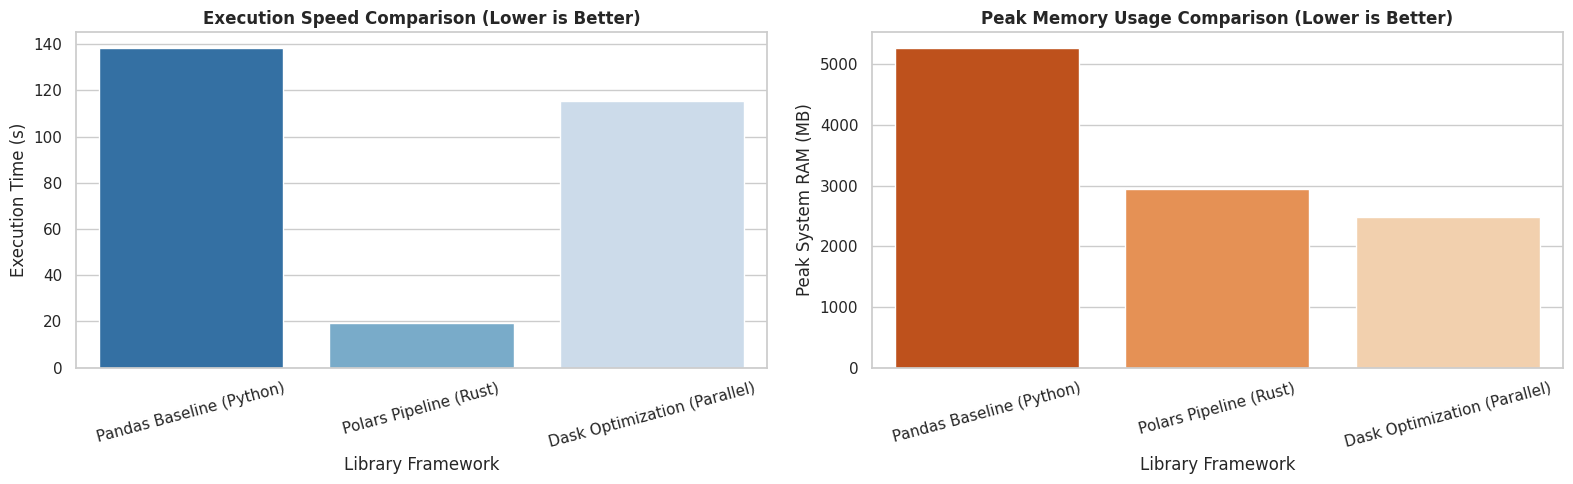

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Construct comparison metrics dataframe
comparison_data = {
    'Library Framework': ['Pandas Baseline (Python)', 'Polars Pipeline (Rust)', 'Dask Optimization (Parallel)'],
    'Execution Time (s)': [time_s3, time_pl, time_s5],
    'Peak System RAM (MB)': [peak_ram_s3, peak_ram_pl, peak_ram_s5],
    'Internal DataFrame Size (MB)': [df_mem_s3, df_mem_pl, df_mem_s5]
}

df_metrics = pd.DataFrame(comparison_data)
print("\n=== BENCHMARK METRICS SUMMARY ===")
display(df_metrics)

# Generate side-by-side bar plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Execution Time Plot (Added 'viridis' style palette to accommodate 3 bars clearly)
sns.barplot(x='Library Framework', y='Execution Time (s)', data=df_metrics, ax=axes[0], palette='Blues_r')
axes[0].set_title('Execution Speed Comparison (Lower is Better)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15) # Rotated slightly for readability

# Peak RAM Plot
sns.barplot(x='Library Framework', y='Peak System RAM (MB)', data=df_metrics, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Peak Memory Usage Comparison (Lower is Better)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15) # Rotated slightly for readability

plt.tight_layout()
plt.show()